Epoch 1/50


c:\Users\Asus-2025\Downloads\ETA\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0625
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0252
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0247
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0247
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0245
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0241
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0240
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0240
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0239
Epoch 10/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0237
Epoch 11/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0239
Epoch 12/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0241
Epoch 13/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0237
Epoch 14/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0235
Epoch 15/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0238
Epoch 16/50
50/50 ━━━━━━━━━━━━

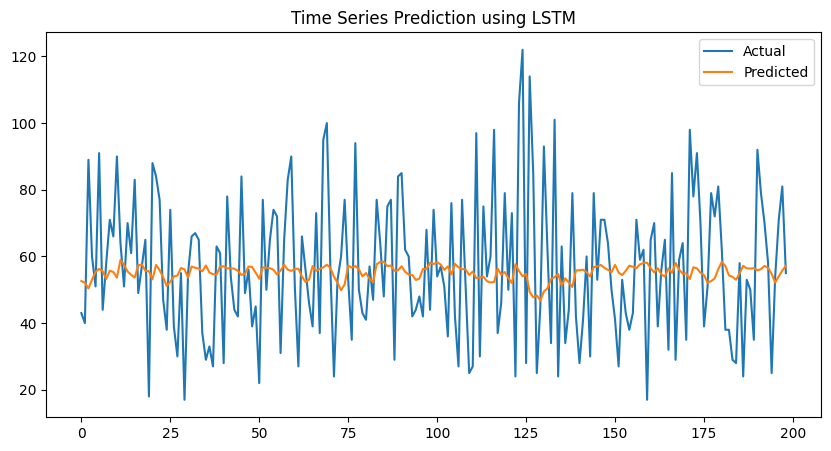

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Load dataset
data = pd.read_csv("Food_Delivery_Times.csv")
dataset = data['Delivery_Time_min'].values.reshape(-1,1)

# Normalize
scaler = MinMaxScaler(feature_range=(0,1))
dataset = scaler.fit_transform(dataset)

# Create sequences
def create_dataset(dataset, time_step=5):
    X, y = [], []
    for i in range(len(dataset)-time_step-1):
        X.append(dataset[i:(i+time_step),0])
        y.append(dataset[i+time_step,0])
    return np.array(X), np.array(y)

time_step = 5
X, y = create_dataset(dataset, time_step)

# Train-test split
train_size = int(len(X)*0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

# Reshape for LSTM
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Build model
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(time_step,1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

# Train
model.fit(X_train, y_train, epochs=50, batch_size=16, verbose=1)

# Prediction
pred = model.predict(X_test)

pred = scaler.inverse_transform(pred)
actual = scaler.inverse_transform(y_test.reshape(-1,1))

# RMSE
rmse = np.sqrt(mean_squared_error(actual, pred))
print("RMSE:", rmse)

# Plot
plt.figure(figsize=(10,5))
plt.plot(actual, label='Actual')
plt.plot(pred, label='Predicted')
plt.legend()
plt.title("Time Series Prediction using LSTM")
plt.show()